[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Extracted
/content/nlp_dataset/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling
['customer_support_text_classification.csv', 'data_dictionary.md']
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

========== TASK 1 ==========
Records: 1500

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
    

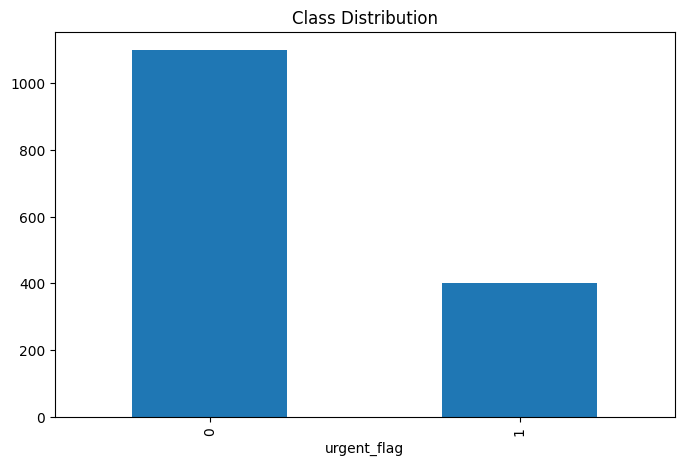


========== TASK 2 ==========
0    tkt
1    tkt
2    tkt
3    tkt
4    tkt
Name: clean_text, dtype: object

========== TASK 3 ==========
Vector shape:
(1500, 1)


Text must be converted into
vectors because machine learning
models cannot understand raw text.

Vectors convert words into
numerical representations.



========== TASK 4 ==========
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       212
           1       0.00      0.00      0.00        88

    accuracy                           0.71       300
   macro avg       0.35      0.50      0.41       300
weighted avg       0.50      0.71      0.59       300



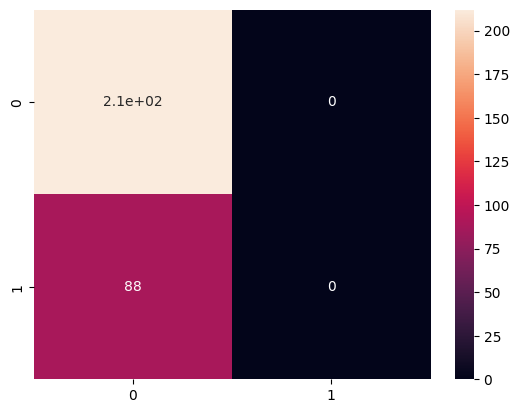


========== TASK 5 ==========


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,170 (1.35 MB)

 Trainable params: 355,170 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7167 - loss: 0.6052 - val_accuracy: 0.7333 - val_loss: 0.5799
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7417 - loss: 0.5729 - val_accuracy: 0.7333 - val_loss: 0.5800
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7417 - loss: 0.5720 - val_accuracy: 0.7333 - val_loss: 0.5801
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7417 - loss: 0.5741 - val_accuracy: 0.7333 - val_loss: 0.5799
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7417 - loss: 0.5749 - val_accuracy: 0.7333 - val_loss: 0.5800
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7417 - loss: 0.5740 - val_accuracy: 0.7333 - val_loss: 0.5799
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7417 - loss: 0.5738 - val_accuracy: 0.7333 - val_loss: 0.5825
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7417 - loss: 0.5736 - val_accuracy: 0.7333 - v

In [ ]:
# ==========================================================
# PART 3 - NLP SEQUENCE MODELING
# TASKS 1 TO 6
# ==========================================================

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense


# ==========================================================
# EXTRACT ZIP
# ==========================================================

zip_files=[f for f in os.listdir('/content')
           if f.endswith('.zip')]

zip_path="/content/"+zip_files[0]

extract_path="/content/nlp_dataset"

with zipfile.ZipFile(
        zip_path,'r'
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )

print("Extracted")


# ==========================================================
# FIND PART 3 DATASET
# ==========================================================

dataset_path="/content/nlp_dataset"
while True:

    dirs=[x for x in os.listdir(dataset_path)
          if os.path.isdir(
              os.path.join(
                  dataset_path,x
              )
          )]
    if len(dirs)==1:

        dataset_path=os.path.join(
            dataset_path,
            dirs[0]
        )
    else:
        break

if "part_3_nlp_sequence_modeling" in os.listdir(dataset_path):
    dataset_path=os.path.join(
        dataset_path,
        "part_3_nlp_sequence_modeling"
    )


print(dataset_path)

print(os.listdir(dataset_path))


# ==========================================================
# LOAD CSV
# ==========================================================

csv_file=[f for f in os.listdir(
dataset_path)

if f.endswith(".csv")
][0]

df=pd.read_csv(

os.path.join(
dataset_path,
csv_file
)
)

print(df.head())


# ==========================================================
# TASK 1
# DATASET UNDERSTANDING
# ==========================================================

print("\n========== TASK 1 ==========")

print(
"Records:",
len(df)
)
print(
"\nColumns:"
)

print(df.columns)

text_col=df.columns[0]
label_col=df.columns[-1]

print(
"\nTarget labels:"
)

print(
df[label_col].unique()
)

print(
"\nSample texts:"
)

print(
df[text_col].head()
)

df["length"]=df[text_col].astype(
str
).apply(
lambda x:
len(x.split())
)


print(
"\nAverage text length:"
)
print(
df["length"].mean()
)



# Class distribution

plt.figure(figsize=(8,5))
df[label_col].value_counts().plot(
kind="bar"
)

plt.title(
"Class Distribution"
)

plt.show()



# ==========================================================
# TASK 2
# PREPROCESSING
# ==========================================================

print("\n========== TASK 2 ==========")

stop_words=set(
stopwords.words(
'english'
)
)

def clean_text(text):

    text=str(text).lower()
    text=re.sub(
    r'[^a-zA-Z ]',
    '',
    text
    )
    words=text.split()
    words=[w for w in words
           if w not in stop_words]

    return " ".join(words)

df["clean_text"]=df[text_col].apply(
clean_text
)

print(
df["clean_text"].head()
)


# ==========================================================
# TASK 3
# TF-IDF VECTORIZATION
# ==========================================================

print("\n========== TASK 3 ==========")

vectorizer=TfidfVectorizer()
X=vectorizer.fit_transform(
df["clean_text"]
)
y=df[label_col]
print(
"Vector shape:"
)
print(X.shape)

print("""

Text must be converted into
vectors because machine learning
models cannot understand raw text.

Vectors convert words into
numerical representations.

""")


# ==========================================================
# TASK 4
# BASELINE MODEL
# LOGISTIC REGRESSION
# ==========================================================

print("\n========== TASK 4 ==========")
X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=0.2,
random_state=42
)


model=LogisticRegression()
model.fit(
X_train,
y_train
)
pred=model.predict(
X_test
)

print(
classification_report(
y_test,
pred,
zero_division=0
)
)

cm=confusion_matrix(
y_test,
pred
)
sns.heatmap(
cm,
annot=True
)
plt.show()



# ==========================================================
# TASK 5
# LSTM MODEL
# ==========================================================

print("\n========== TASK 5 ==========")

tokenizer=Tokenizer(
num_words=5000
)
tokenizer.fit_on_texts(
df["clean_text"]
)

seq=tokenizer.texts_to_sequences(
df["clean_text"]
)
maxlen=100
X_pad=pad_sequences(
seq,
maxlen=maxlen,
padding='post'
)


from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y_enc=encoder.fit_transform(
y
)

X_train,X_test,y_train,y_test=\
train_test_split(
X_pad,
y_enc,
test_size=0.2,
random_state=42
)

lstm=Sequential([

tf.keras.Input(
shape=(maxlen,)
),

Embedding(
input_dim=5000,
output_dim=64
),

LSTM(64),

Dense(
32,
activation='relu'
),

Dense(
len(np.unique(y_enc)),
activation='softmax'
)

])

lstm.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

lstm.summary()

history=lstm.fit(
X_train,
y_train,
epochs=15,
validation_split=0.2
)



loss,acc=lstm.evaluate(
X_test,
y_test
)
print(
"LSTM Accuracy:",
acc
)

# =====================================
# SAMPLE PREDICTIONS
# Add HERE
# =====================================

text_col="customer_message"
label_col="sentiment_label"

sample_texts=X_test[:5]

pred_probs=lstm.predict(
sample_texts
)

pred_labels=np.argmax(

pred_probs,

axis=1

)


actual_labels=y_test[:5]


decoded_actual=encoder.inverse_transform(

actual_labels

)

decoded_pred=encoder.inverse_transform(

pred_labels

)



for i in range(5):

    print(
    "Customer Message:"
    )

    print(
    df.iloc[i][text_col]
    )

    print(

    "\nActual Label:",

    decoded_actual[i]

    )

    print(

    "Predicted Label:",

    decoded_pred[i]

    )

    print(
    "\n--------------------\n"
    )


# ==========================================================
# TASK 6
# EXPLANATIONS
# ==========================================================

print("""

========== TASK 6 ==========

1. Why RNN struggles:
RNN forgets older information
when sequences become long.

This causes vanishing gradients.


2. How LSTM helps:
LSTM has memory cells and gates
to retain important information.


3. What attention solves:
Attention lets the model focus
on important words rather than
all words equally.


4. Why transformers matter:
Transformers process sequences
in parallel and power models
such as GPT and modern Generative AI.

""")

print("DONE")